# Cluster Results — Spin-Bath Posterior Visualisation
---
**Purpose**  
Load and visualise the output of a multi-trajectory RJMCMC cluster run
produced by `run_cluster_inference.py`.

**Expected layout on disk**
```
inference_results/
    results_combined.pkl   ← single file combining all trajectories
```

**What this notebook shows**
1. Run metadata and a per-trajectory timing / size summary.
2. Convergence diagnostics (error trace + k-trace) for all trajectories and individually.
3. Posterior distribution for each trajectory side-by-side.
4. Combined posterior pooled across all trajectories.
5. Ranked summary tables of top spin-bath configurations.

> *Only edit the USER SETTINGS cell.  All other cells run without modification.*

## 0 · Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from plot_cluster_results import (
    load_results,
    plot_convergence_single,
    plot_all_convergence,
    plot_posterior_single,
    plot_all_posteriors,
    plot_combined_posterior,
    print_trajectory_summary,
    build_pooled_state,
    save_pooled_state,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Imports OK ✓")


Imports OK ✓


## 1 · User Settings
Edit **only this cell**.

In [2]:
# =============================================================================
#  USER SETTINGS
# =============================================================================

# Path to the combined results pkl written by run_cluster_inference.py
RESULTS_FILE = "inference_results/results_combined.pkl"

# Is this a simulation (ground-truth known) or a real experiment?
#   True  → ground-truth spin locations shown as red crosses on posterior plots
#   False → ground-truth overlay suppressed
IS_SIMULATION = False

# Ground-truth spin indices (only used when IS_SIMULATION = True)
GROUND_TRUTH_SPINS = [245, 618, 714, 900, 1100]

# How many top-ranked spin-bath configurations to show in the summary table
TOP_N = 5

# Which individual trajectory to inspect in detail (0-indexed)
INSPECT_TRAJ_ID = 0

# Custom burn-in cutoff for convergence plots
# Set to None to use the value stored in the results file
BURN_IN_OVERRIDE = None

# ── Pooled state export (Section 9) ─────────────────────────────────────────
# Output path for the pooled state pkl
POOLED_STATE_PATH = "spin_bath_XY4_exp1_posterior_1_pool.pkl"

# Trajectories to include in the pooled state.
# Set to None to pool ALL trajectories.
# To exclude unconverged chains, pass a list, e.g. [0, 1, 3, 4]
POOL_TRAJECTORY_IDS = None


## 2 · Load Results

Loads `results_combined.pkl` and prints a summary of every trajectory
(trajectory ID, seed, wall time, number of posterior configurations).

In [3]:
results = load_results(RESULTS_FILE)


Loaded results_combined.pkl
  Trajectories : 5
  Steps / traj : 25000  (burn-in: 12500)
  Spins in lib : 3557
  traj 0  seed=42  elapsed=11.4 min  posterior configs=3597
  traj 1  seed=1042  elapsed=11.1 min  posterior configs=3584
  traj 2  seed=2042  elapsed=11.3 min  posterior configs=3590
  traj 3  seed=3042  elapsed=11.3 min  posterior configs=3521
  traj 4  seed=4042  elapsed=11.3 min  posterior configs=3613


## 3 · Run Metadata

Quick overview of the cluster run: number of trajectories, MCMC steps,
burn-in, and per-trajectory timing.

In [4]:
n_traj  = results["num_trajectories"]
n_steps = results["num_trials"]
burn_in = results["burn_in"]
n_spins = len(results["hf_df"])

print(f"Trajectories      : {n_traj}")
print(f"Steps / trajectory: {n_steps:,}")
print(f"Burn-in           : {burn_in:,}  ({100*burn_in/n_steps:.0f}% of steps)")
print(f"Post-burn samples : {n_steps - burn_in:,}")
print(f"Spins in library  : {n_spins}")
print()

rows = []
for t in results["trajectories"]:
    rows.append({
        "traj_id"          : t["traj_id"],
        "seed"             : t["seed"],
        "elapsed (min)"    : round(t["elapsed_seconds"] / 60, 1),
        "posterior configs": len(t["posterior"]),
        "top weight"       : round(
            max(d["weight"] for d in t["posterior"]), 4
        ),
    })
pd.DataFrame(rows).set_index("traj_id")


Trajectories      : 5
Steps / trajectory: 25,000
Burn-in           : 12,500  (50% of steps)
Post-burn samples : 12,500
Spins in library  : 3557



,seed,elapsed (min),posterior configs,top weight
traj_id,,,,
0,42,11.4,3597,0.0034
1,1042,11.1,3584,0.0034
2,2042,11.3,3590,0.0037
3,3042,11.3,3521,0.0033
4,4042,11.3,3613,0.0033


## 4 · Convergence Diagnostics

### 4a · All trajectories — overview

L2 error trace (top row) and spin-count k trace (bottom row) for every
trajectory, plotted side by side.  The dashed red line marks the burn-in cutoff.
Trajectories that mix well show a rapid initial drop in error followed by
stationary fluctuations.

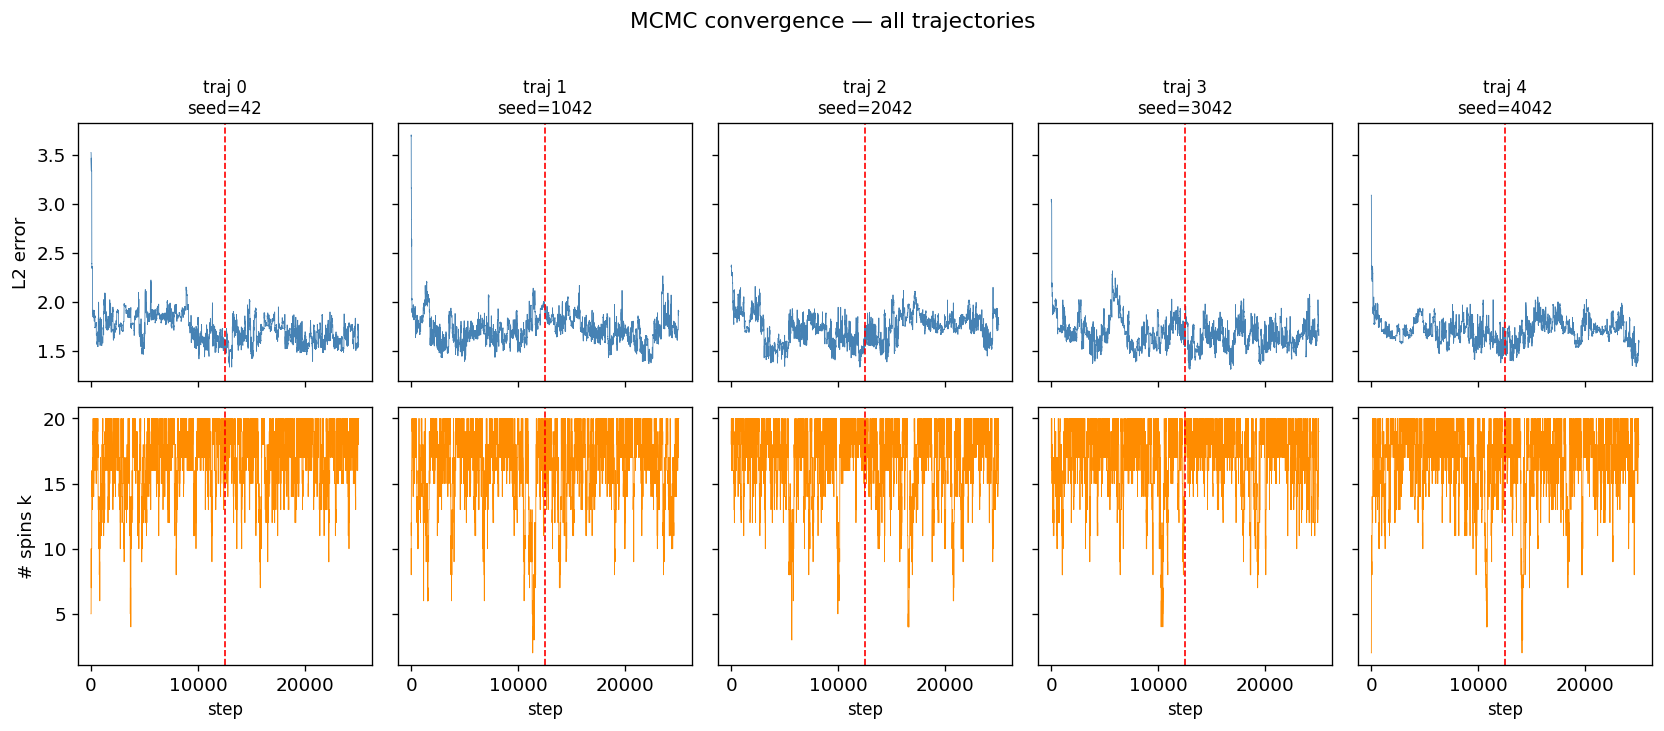

In [5]:
plot_all_convergence(results, burn_in=BURN_IN_OVERRIDE)


### 4b · Individual trajectory — detailed view

Inspect one trajectory in full detail.  Change `INSPECT_TRAJ_ID` in the
USER SETTINGS cell to switch trajectories.

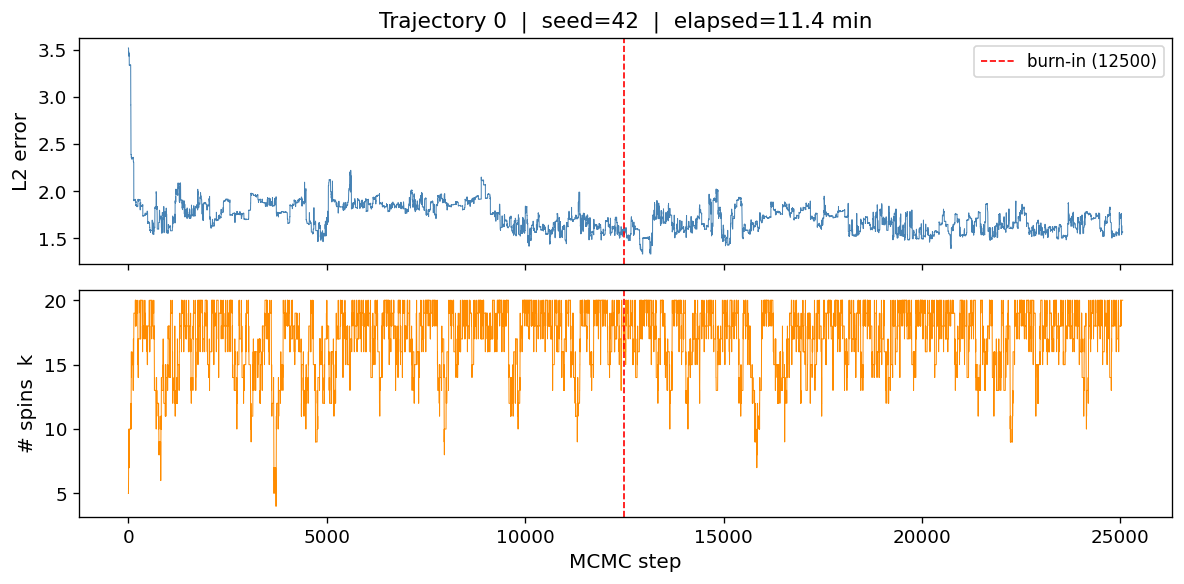

In [6]:
plot_convergence_single(results, traj_id=INSPECT_TRAJ_ID, burn_in=BURN_IN_OVERRIDE)


### 4c · All trajectories individually

Loops through every trajectory for a thorough per-chain inspection.

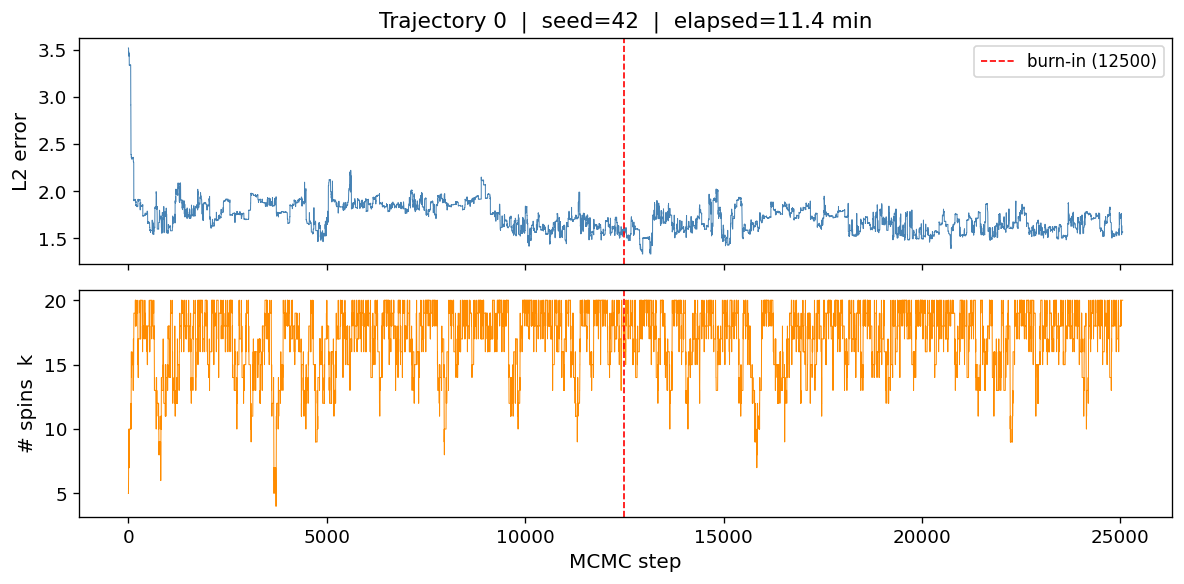

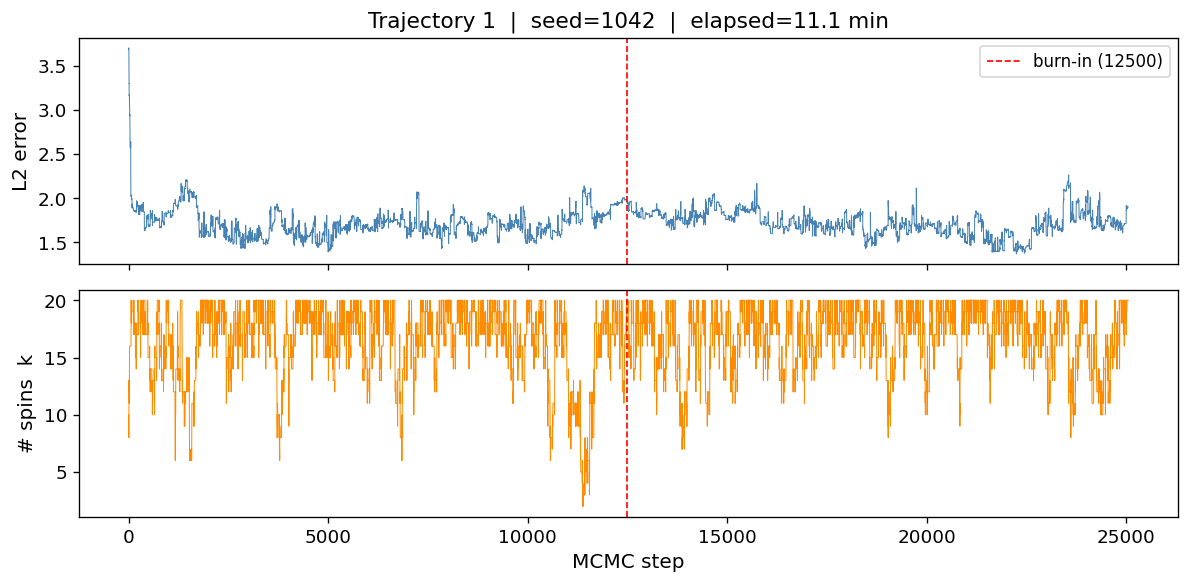

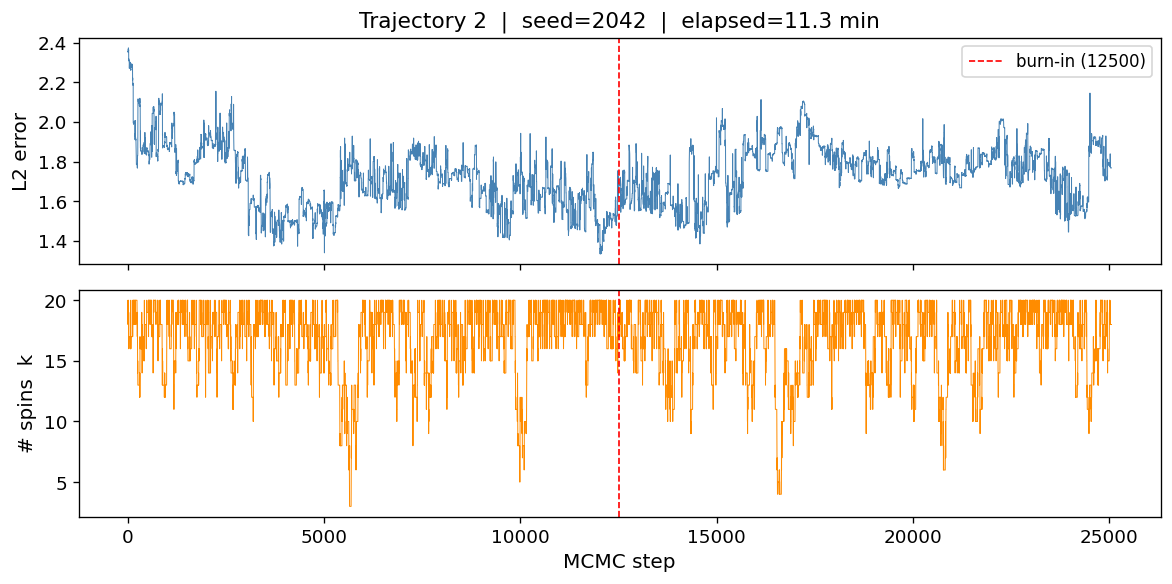

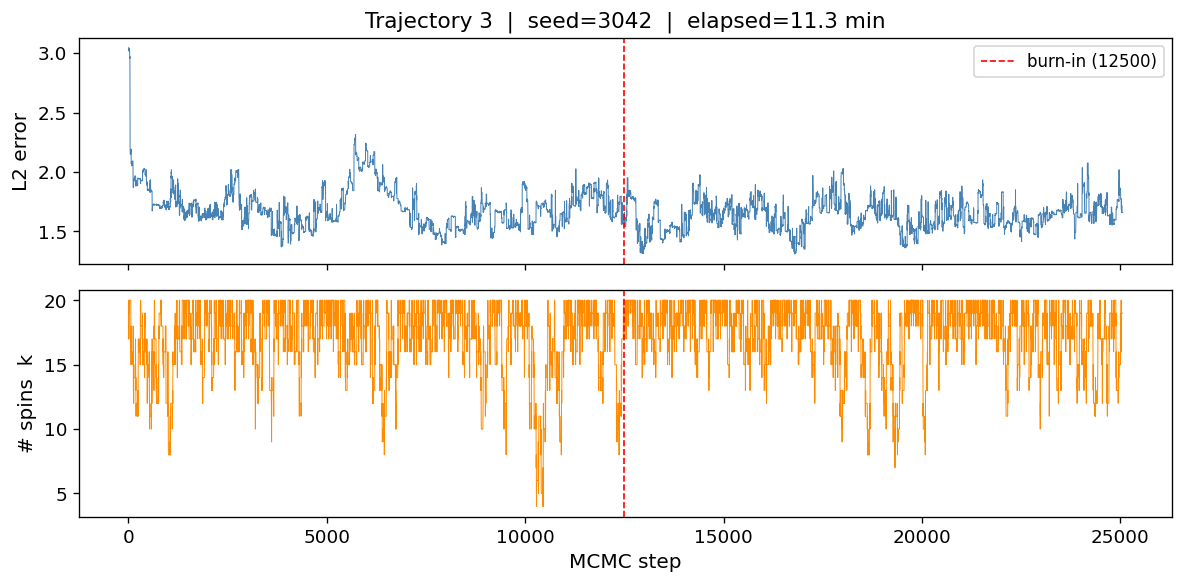

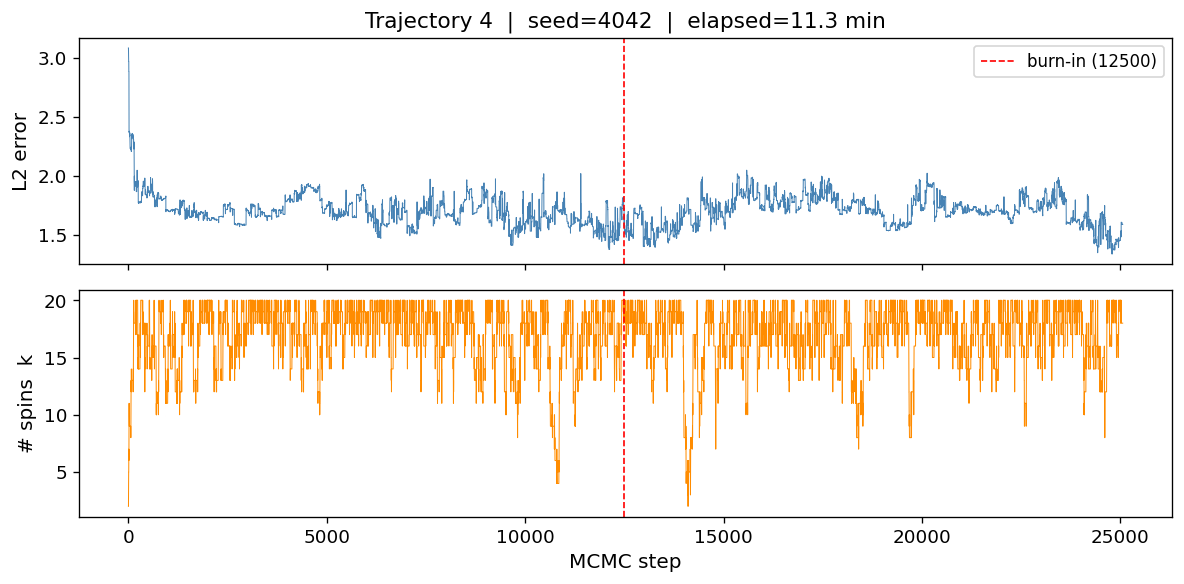

In [7]:
for traj_id in range(results["num_trajectories"]):
    plot_convergence_single(results, traj_id=traj_id, burn_in=BURN_IN_OVERRIDE)


## 5 · Posterior Distributions

### 5a · All trajectories side-by-side

Each panel shows the (A_par, A_perp) posterior scatter for one trajectory.
Point opacity encodes posterior weight.  Agreement across trajectories is a
sign of good mixing.

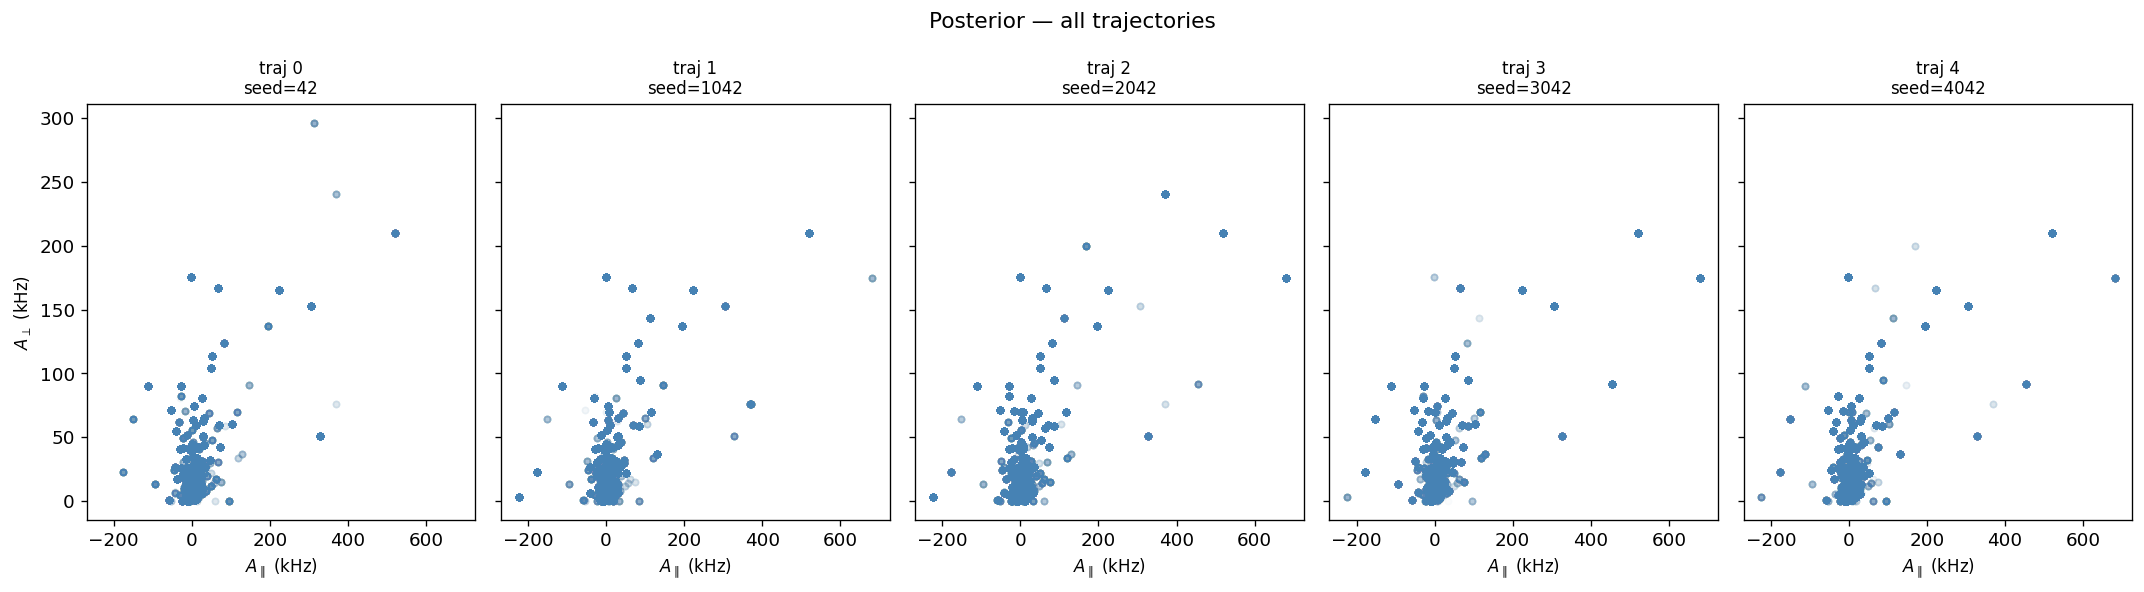

In [8]:
gt = GROUND_TRUTH_SPINS if IS_SIMULATION else None
plot_all_posteriors(
    results,
    is_simulation       = IS_SIMULATION,
    ground_truth_spins  = gt,
)


### 5b · Individual trajectory posterior

Larger, higher-resolution view for a single chain.

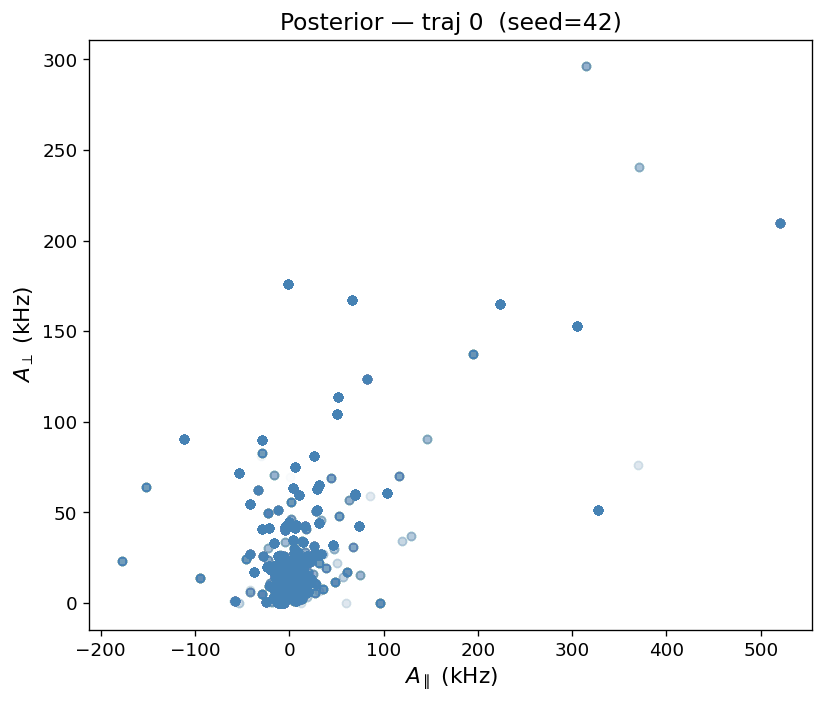

In [9]:
gt = GROUND_TRUTH_SPINS if IS_SIMULATION else None
plot_posterior_single(
    results,
    traj_id             = INSPECT_TRAJ_ID,
    is_simulation       = IS_SIMULATION,
    ground_truth_spins  = gt,
)


### 5c · All individual posteriors

Full-size posterior plot for every trajectory.

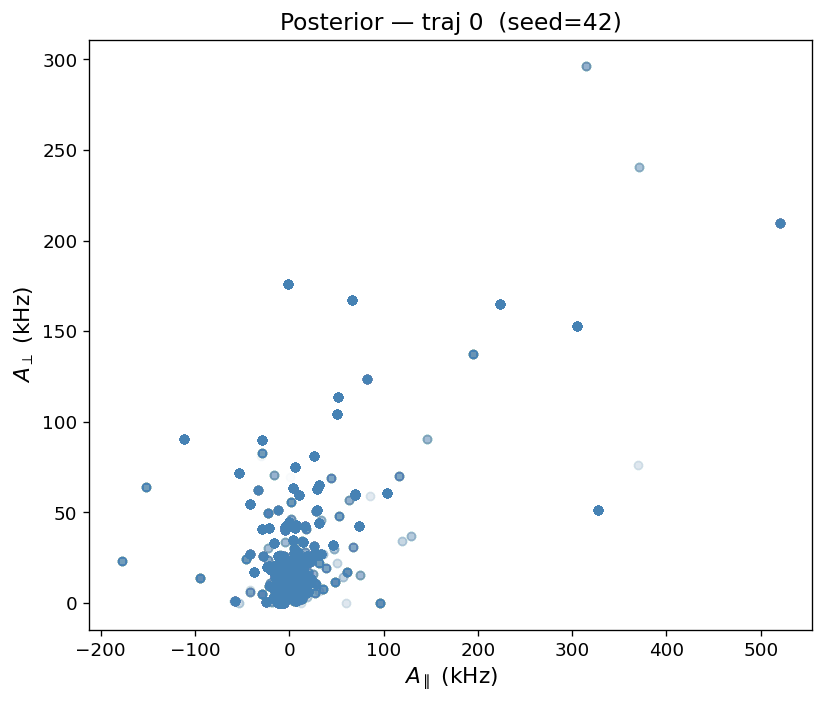

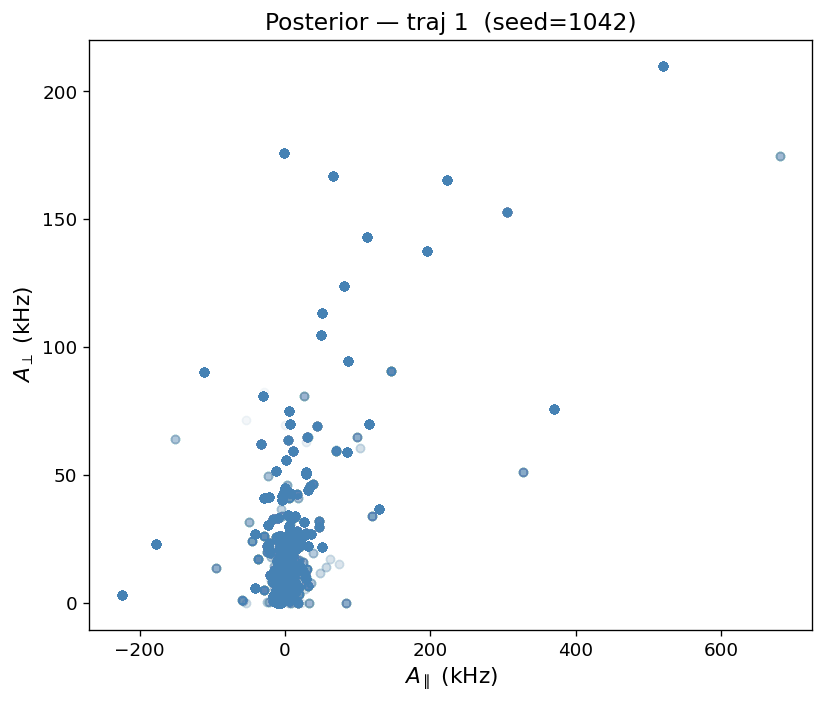

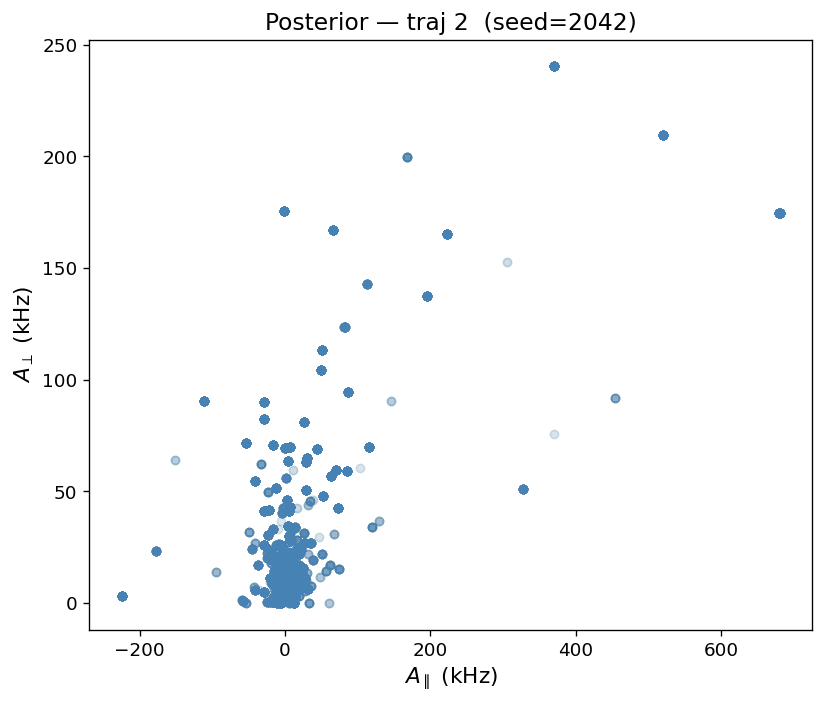

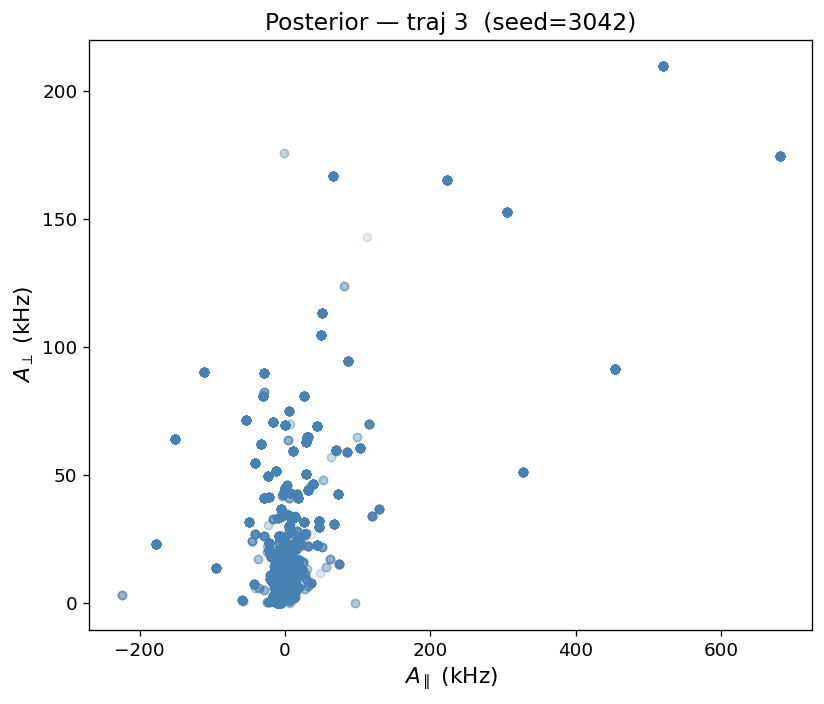

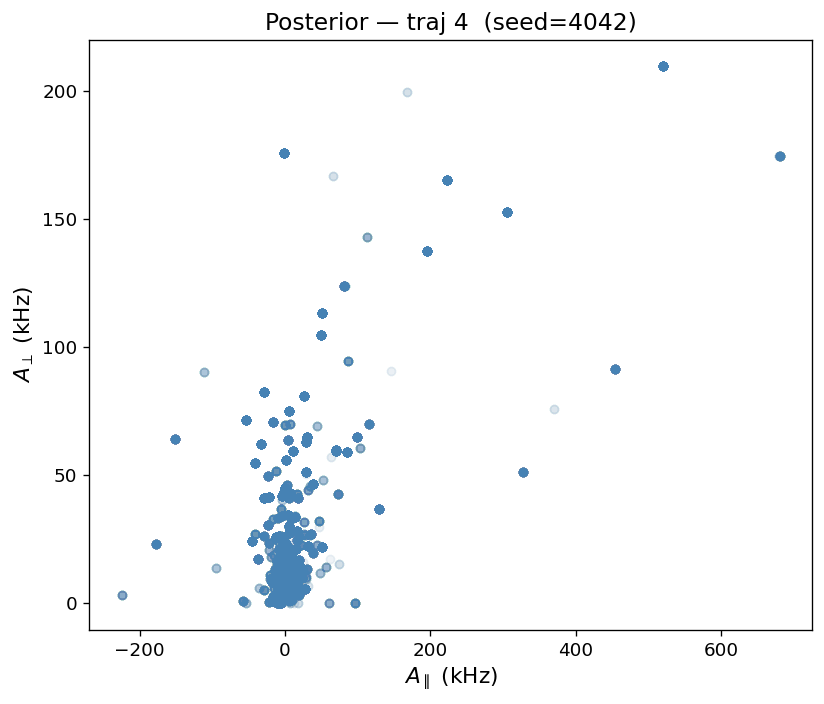

In [10]:
gt = GROUND_TRUTH_SPINS if IS_SIMULATION else None
for traj_id in range(results["num_trajectories"]):
    plot_posterior_single(
        results,
        traj_id             = traj_id,
        is_simulation       = IS_SIMULATION,
        ground_truth_spins  = gt,
    )


## 6 · Combined Posterior (all trajectories pooled)

All posterior samples from every trajectory are pooled and re-normalised.
This gives the most data-rich view of the posterior and helps identify
robust spin-bath configurations that appear consistently across chains.

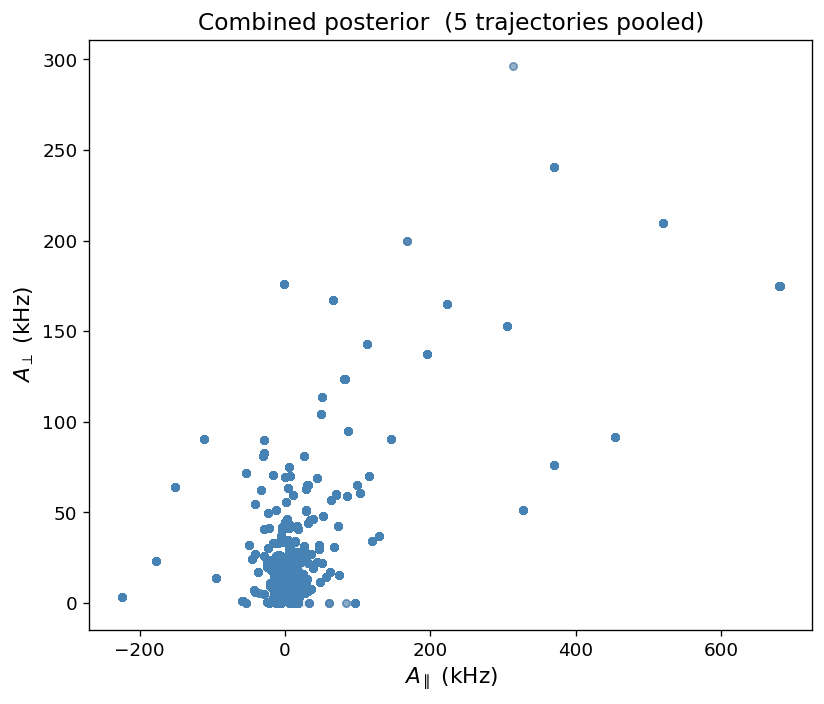

In [11]:
gt = GROUND_TRUTH_SPINS if IS_SIMULATION else None
plot_combined_posterior(
    results,
    is_simulation       = IS_SIMULATION,
    ground_truth_spins  = gt,
)


## 7 · Summary Tables

### 7a · Top configurations per trajectory

Ranked table of the highest-weight spin-bath configurations for every
trajectory.  Columns: weight, MCMC count, number of spins (k), and the
(A_par, A_perp) pairs of each spin in the bath.

In [12]:
summary_df = print_trajectory_summary(results, top_n=TOP_N)


              seed  weight  count   k                                                                                                                                                                                                                                                                                                   pairs
traj_id rank                                                                                                                                                                                                                                                                                                                                 
0       1       42  0.0034     43  18                                        (-41.37,54.53); (-9.51,7.24); (-8.91,4.89); (-7.80,12.53); (-4.92,7.80); (-3.71,17.96); (-0.67,7.05); (1.23,5.25); (2.72,12.06); (3.74,5.47); (4.65,7.44); (7.13,5.38); (7.62,0.96); (10.00,8.48); (15.33,20.90); (31.05,64.78); (51.56,113.39); (223.39,165.23

### 7b · Cross-trajectory comparison of top-1 configuration

Quick check of whether all chains agree on the single most probable bath.

In [13]:
rows = []
for t in results["trajectories"]:
    top1 = max(t["posterior"], key=lambda d: d["weight"])
    pairs_str = "; ".join(
        f"({ap:.2f}, {aperp:.2f})" for ap, aperp in top1["pairs"]
    )
    rows.append({
        "traj_id" : t["traj_id"],
        "seed"    : t["seed"],
        "weight"  : round(top1["weight"], 4),
        "k"       : len(top1["pairs"]),
        "top bath (A_par, A_perp)": pairs_str,
    })
df_top1 = pd.DataFrame(rows).set_index("traj_id")
print("Top-1 bath per trajectory:")
display(df_top1)


Top-1 bath per trajectory:


,seed,weight,k,"top bath (A_par, A_perp)"
traj_id,,,,
0,42,0.0034,18,"(-41.37, 54.53); (-9.51, 7.24); (-8.91, 4.89);..."
1,1042,0.0034,20,"(-111.71, 90.20); (-41.71, 26.76); (-14.43, 13..."
2,2042,0.0037,4,"(-28.35, 89.86); (6.12, 41.09); (26.44, 80.95)..."
3,3042,0.0033,17,"(-22.74, 49.71); (-15.23, 18.49); (-11.65, 7.3..."
4,4042,0.0033,18,"(-28.72, 82.45); (-28.13, 26.00); (-13.37, 8.9..."


### 7c · Pooled top configurations across all trajectories

Aggregate posterior weights across all trajectories to find globally
dominant bath configurations.

In [14]:
from collections import defaultdict

# Index baths by their sorted spin-index tuple
aggregated = defaultdict(lambda: {"weight": 0.0, "count": 0, "traj_ids": []})

for t in results["trajectories"]:
    traj_id = t["traj_id"]
    for d in t["posterior"]:
        key = tuple(sorted(d["indices"]))
        aggregated[key]["weight"]   += d["weight"]
        aggregated[key]["count"]    += d["count"]
        aggregated[key]["traj_ids"].append(traj_id)
        aggregated[key]["pairs"]     = d["pairs"]   # store for display

# Normalise pooled weights
total_w = sum(v["weight"] for v in aggregated.values())
for v in aggregated.values():
    v["weight"] /= total_w

# Sort by pooled weight
ranked = sorted(aggregated.values(), key=lambda v: v["weight"], reverse=True)

rows = []
hf_df = results["hf_df"]
for rank, bath in enumerate(ranked[:TOP_N], start=1):
    pairs_str = "; ".join(
        f"({ap:.2f}, {aperp:.2f})" for ap, aperp in bath["pairs"]
    )
    rows.append({
        "rank"          : rank,
        "pooled weight" : round(bath["weight"], 4),
        "total count"   : bath["count"],
        "k"             : len(bath["pairs"]),
        "seen in trajs" : sorted(set(bath["traj_ids"])),
        "pairs"         : pairs_str,
    })

df_pooled = pd.DataFrame(rows).set_index("rank")
print(f"Top-{TOP_N} bath configurations pooled across all trajectories:")
display(df_pooled)


Top-5 bath configurations pooled across all trajectories:


,pooled weight,total count,k,seen in trajs,pairs
rank,,,,,
1,0.0007,46,4,[2],"(-28.35, 89.86); (6.12, 41.09); (26.44, 80.95)..."
2,0.0007,43,18,[0],"(-41.37, 54.53); (-9.51, 7.24); (-8.91, 4.89);..."
3,0.0007,43,20,[1],"(-111.71, 90.20); (-41.71, 26.76); (-14.43, 13..."
4,0.0007,43,20,[1],"(-111.71, 90.20); (-8.19, 17.33); (-6.88, 11.5..."
5,0.0007,42,18,[0],"(-21.57, 41.50); (-21.35, 20.56); (-9.16, 3.41..."


## 8 · Raw Measurement Data

Plot the coherence data used for inference, as a sanity check.

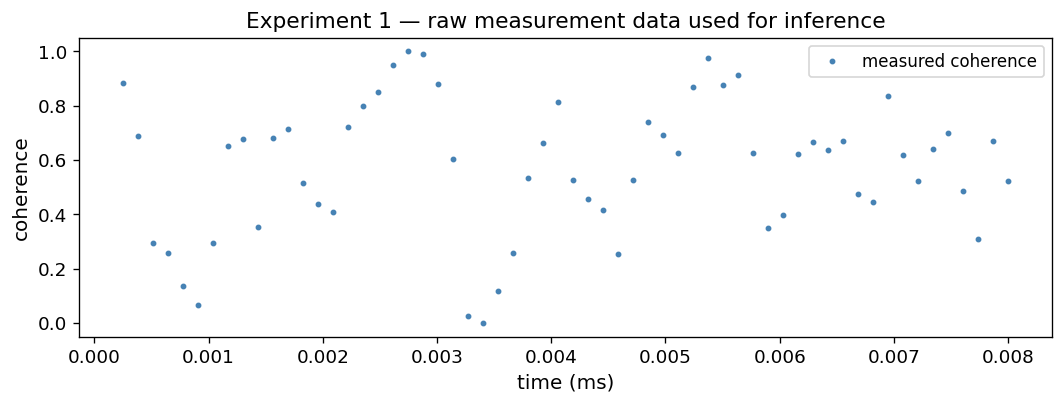

Time range : 0.00025 – 0.00800 ms  (60 points)
Signal range: 0.0000 – 1.0000


In [15]:
times  = results["exp_params"]["timepoints"][0]
signal = results["coherence_data"][0]

plt.figure(figsize=(9, 3.5))
plt.plot(times, signal, ".", ms=5, color="steelblue", label="measured coherence")
plt.xlabel("time (ms)", fontsize=12)
plt.ylabel("coherence", fontsize=12)
plt.title("Experiment 1 — raw measurement data used for inference", fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Time range : {times[0]:.5f} – {times[-1]:.5f} ms  ({len(times)} points)")
print(f"Signal range: {signal.min():.4f} – {signal.max():.4f}")


## 9 · Export Pooled State for Next-Experiment Design

Packages the pooled posterior into a `workflow_pipeline`-compatible state
pkl so it can be loaded directly in `spin_bath_inference_workflow.ipynb`
to run experiment design without re-running RJMCMC.

**After saving here, use this in the workflow notebook:**
```python
state = load_state("spin_bath_XY4_exp1_posterior_1.pkl")

candidates       = build_candidate_experiments(config)
recommendation_1 = suggest_next_experiment(state, config, candidates)
display_recommendation(recommendation_1)
plot_information_diagnostic(state, recommendation_1, config, is_simulation=False)
```

> Edit `POOLED_STATE_PATH` and `POOL_TRAJECTORY_IDS` in the USER SETTINGS
> cell (Section 1) to control the output path and which chains to include.
> Leave `POOL_TRAJECTORY_IDS = None` to pool all trajectories.
> To exclude unconverged chains set e.g. `POOL_TRAJECTORY_IDS = [0, 1, 3, 4]`.

In [16]:
# ── Optional: inspect which trajectories look well-converged ────────────────
# Use the convergence plots in Section 4 to decide.
# Then set POOL_TRAJECTORY_IDS in USER SETTINGS to exclude any bad chains.

import numpy as np

print("Trajectory convergence quick-check (mean post-burn-in L2 error):")
bi = results["burn_in"]
for t in results["trajectories"]:
    err        = np.asarray(t["error_samples"])
    mean_final = float(np.mean(err[bi:]))
    std_final  = float(np.std(err[bi:]))
    print(
        f"  traj {t['traj_id']}  seed={t['seed']}  "
        f"mean={mean_final:.4f}  std={std_final:.4f}  "
        f"posterior configs={len(t['posterior'])}"
    )


Trajectory convergence quick-check (mean post-burn-in L2 error):
  traj 0  seed=42  mean=1.6536  std=0.1096  posterior configs=3597
  traj 1  seed=1042  mean=1.7151  std=0.1403  posterior configs=3584
  traj 2  seed=2042  mean=1.7592  std=0.1307  posterior configs=3590
  traj 3  seed=3042  mean=1.6286  std=0.1200  posterior configs=3521
  traj 4  seed=4042  mean=1.7022  std=0.1256  posterior configs=3613


In [17]:
# ── Build and preview the pooled state (does NOT write to disk yet) ─────────
pooled_state = build_pooled_state(results, trajectory_ids=POOL_TRAJECTORY_IDS)

n_pool = (
    len(POOL_TRAJECTORY_IDS) if POOL_TRAJECTORY_IDS is not None
    else results["num_trajectories"]
)

print(f"Pooled state summary:")
print(f"  Trajectories pooled      : {n_pool}")
print(f"  Posterior configurations : {len(pooled_state['posterior'])}")
print(f"  Total MCMC steps stored  : {len(pooled_state['error_samples']):,}")

# Top-5 pooled posterior entries
top5 = sorted(pooled_state["posterior"],
              key=lambda d: d["weight"], reverse=True)[:5]
rows = []
for rank, bath in enumerate(top5, start=1):
    pairs_str = "; ".join(
        f"({ap:.2f},{aperp:.2f})" for ap, aperp in bath["pairs"]
    )
    rows.append({"rank": rank, "weight": round(bath["weight"], 5),
                 "k": len(bath["pairs"]), "pairs": pairs_str})

print("\nTop-5 pooled posterior configurations:")
import pandas as pd
display(pd.DataFrame(rows).set_index("rank"))


Pooled state summary:
  Trajectories pooled      : 5
  Posterior configurations : 17905
  Total MCMC steps stored  : 125,285

Top-5 pooled posterior configurations:


,weight,k,pairs
rank,,,
1,0.00073,4,"(-28.35,89.86); (6.12,41.09); (26.44,80.95); (..."
2,0.00068,18,"(-41.37,54.53); (-9.51,7.24); (-8.91,4.89); (-..."
3,0.00068,20,"(-111.71,90.20); (-41.71,26.76); (-14.43,13.00..."
4,0.00068,20,"(-111.71,90.20); (-8.19,17.33); (-6.88,11.58);..."
5,0.00067,18,"(-21.57,41.50); (-21.35,20.56); (-9.16,3.41); ..."


In [22]:
top5[1]

{'pairs': ((np.float64(-41.373041750999995), np.float64(54.533332601248745)),
  (np.float64(-9.514402606800001), np.float64(7.242723407368509)),
  (np.float64(-8.907101760666599), np.float64(4.886833039680078)),
  (np.float64(-7.7990785743333), np.float64(12.525536245389251)),
  (np.float64(-4.924868619600001), np.float64(7.7978207810286015)),
  (np.float64(-3.706937641), np.float64(17.95913969426003)),
  (np.float64(-0.6655342887333), np.float64(7.048894801524555)),
  (np.float64(1.2318417675166), np.float64(5.2456549002582165)),
  (np.float64(2.7214753436000003), np.float64(12.061594881778491)),
  (np.float64(3.7418274970666), np.float64(5.46500649149035)),
  (np.float64(4.6496567842), np.float64(7.437856794190734)),
  (np.float64(7.1326599066666), np.float64(5.378163236450078)),
  (np.float64(7.6207183586666005), np.float64(0.9600963110074036)),
  (np.float64(10.002370867333301), np.float64(8.476659887464082)),
  (np.float64(15.3349568613333), np.float64(20.901167862471553)),
  (np.

In [18]:
# ── Save the pooled state to disk ───────────────────────────────────────────
save_pooled_state(
    results,
    output_path    = POOLED_STATE_PATH,
    trajectory_ids = POOL_TRAJECTORY_IDS,
)


Building pooled state from 5 trajectories …
Pooled state saved → spin_bath_XY4_exp1_posterior_1_pool.pkl  (118.9 MB)
  Trajectories pooled      : 5
  Posterior configurations : 17905
  Total MCMC steps stored  : 125,285

Load in spin_bath_inference_workflow.ipynb with:
    state = load_state("spin_bath_XY4_exp1_posterior_1_pool.pkl")
